# **PRÁTICA 2**
# Pré-processamento DDPM

________________________________________________________

#### SEMATEC 2026
**Curso**: Hackeando uma IA - Técnicas de Ataque e Defesa em Modelos de Difusão

**Prof.:** Jean Phelipe de Oliveira Lima

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Leitura da Imagem

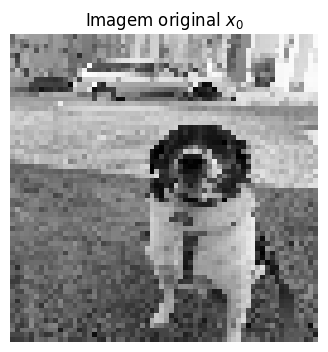

In [3]:
nome_arquivo = "/content/kevin.jpg"

# Lê o arquivo como imagem em escala de cinza
imagem = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

# Redimensiona a imagem para 64 x 64 pixels
imagem = cv2.resize(imagem, (64, 64))

# Converte de uint8 para float32
imagem = imagem.astype(np.float32)

# Normaliza os pixels de [0, 255] para [-1, 1]
x0 = (imagem / 127.5) - 1.0

plt.figure(figsize=(4, 4))
plt.imshow(x0, cmap="gray", vmin=-1, vmax=1)
plt.title("Imagem original $x_0$")
plt.axis("off")
plt.show()

## Definição de Noise Schedule

In [51]:
# Número total de etapas da difusão
T = 1000

# Primeiro e último valor do noise schedule
beta_inicial = 0.0001
beta_final = 0.02

# Noise schedule linear
betas = np.linspace(
    beta_inicial,
    beta_final,
    T,
    dtype=np.float32
)

# Alpha representa a preservação em cada etapa
alphas = 1.0 - betas

# Alpha barra representa a preservação acumulada
alphas_barra = np.cumprod(alphas)

### Visualização do Noise Schedule

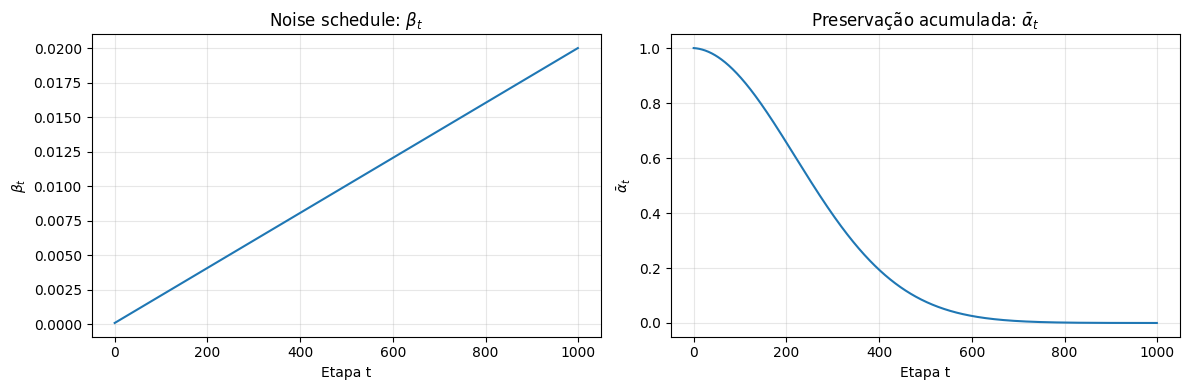

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

# Intensidade de ruído de cada etapa
eixos[0].plot(betas)
eixos[0].set_title("Noise schedule: $\\beta_t$")
eixos[0].set_xlabel("Etapa t")
eixos[0].set_ylabel("$\\beta_t$")
eixos[0].grid(alpha=0.3)

# Preservação acumulada do sinal
eixos[1].plot(alphas_barra)
eixos[1].set_title("Preservação acumulada: $\\bar{\\alpha}_t$")
eixos[1].set_xlabel("Etapa t")
eixos[1].set_ylabel("$\\bar{\\alpha}_t$")
eixos[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Geração do Ruído Gaussiano ϵ

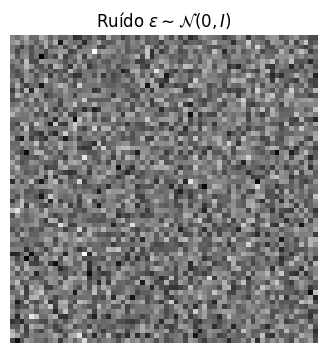

In [9]:
# Define uma semente para a demonstração ser reproduzível
np.random.seed(42)

# Parâmetros para a distribuição gaussiana
media = 0.0
desvio_padrao = 1.0

# Cria uma matriz de ruído com o mesmo formato da imagem
epsilon = np.random.normal(
    loc=media,
    scale=desvio_padrao,
    size=x0.shape
).astype(np.float32)

plt.figure(figsize=(4, 4))
plt.imshow(epsilon, cmap="gray")
plt.title("Ruído $\\epsilon \\sim \\mathcal{N}(0,I)$")
plt.axis("off")
plt.show()

## Cálculo de $X_t$

Função aplica a fórmula:

## $X_t = \widehat{\alpha_t}^{\frac{1}{2}}X_0 + (1-\widehat{\alpha_t})^{\frac{1}{2}}\epsilon$

In [10]:
def adicionar_ruido_direto(x0, t, epsilon):
    """
    Calcula x_t diretamente a partir de x_0.

    x0: imagem original normalizada
    t: índice da etapa, entre 0 e T-1
    epsilon: ruído gaussiano
    """

    alpha_barra_t = alphas_barra[t]

    parte_imagem = np.sqrt(alpha_barra_t) * x0
    parte_ruido = np.sqrt(1.0 - alpha_barra_t) * epsilon

    xt = parte_imagem + parte_ruido

    return xt, parte_imagem, parte_ruido

## Testes

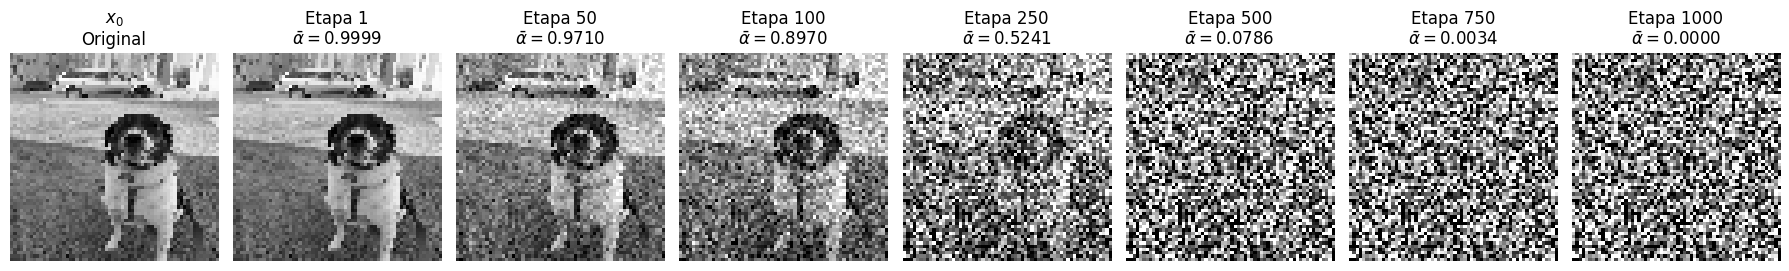

In [10]:
etapas = [0, 49, 99, 249, 499, 749, 999]

fig, eixos = plt.subplots(
    1,
    len(etapas) + 1,
    figsize=(18, 3)
)

# Imagem original
eixos[0].imshow(x0, cmap="gray", vmin=-1, vmax=1)
eixos[0].set_title("$x_0$\nOriginal")
eixos[0].axis("off")

# Imagens em diferentes níveis de ruído
for eixo, t in zip(eixos[1:], etapas):
    xt, _, _ = adicionar_ruido_direto(x0, t, epsilon)

    eixo.imshow(xt, cmap="gray", vmin=-1, vmax=1)
    eixo.set_title(
        f"Etapa {t + 1}\n"
        f"$\\bar{{\\alpha}}={alphas_barra[t]:.4f}$"
    )
    eixo.axis("off")

plt.tight_layout()
plt.show()

## Representação Gráfica do Cálculo de $X_t$

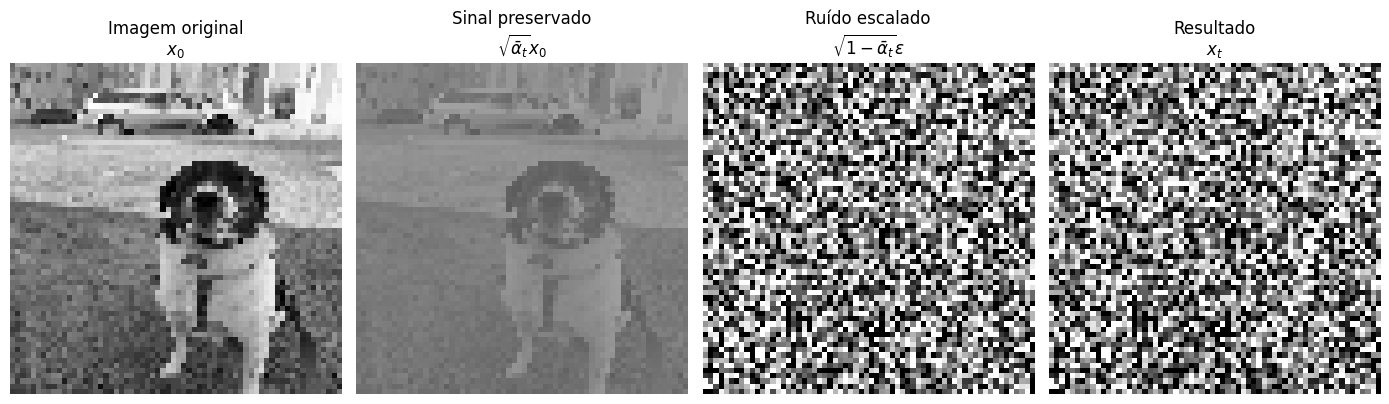

In [52]:
t = 500

xt, parte_imagem, parte_ruido = adicionar_ruido_direto(
    x0,
    t,
    epsilon
)

fig, eixos = plt.subplots(1, 4, figsize=(14, 4))

eixos[0].imshow(x0, cmap="gray", vmin=-1, vmax=1)
eixos[0].set_title("Imagem original\n$x_0$")

eixos[1].imshow(parte_imagem, cmap="gray", vmin=-1, vmax=1)
eixos[1].set_title(
    "Sinal preservado\n"
    "$\\sqrt{\\bar{\\alpha}_t}x_0$"
)

eixos[2].imshow(parte_ruido, cmap="gray", vmin=-1, vmax=1)
eixos[2].set_title(
    "Ruído escalado\n"
    "$\\sqrt{1-\\bar{\\alpha}_t}\\epsilon$"
)

eixos[3].imshow(xt, cmap="gray", vmin=-1, vmax=1)
eixos[3].set_title("Resultado\n$x_t$")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()

## Preparando dados para treino

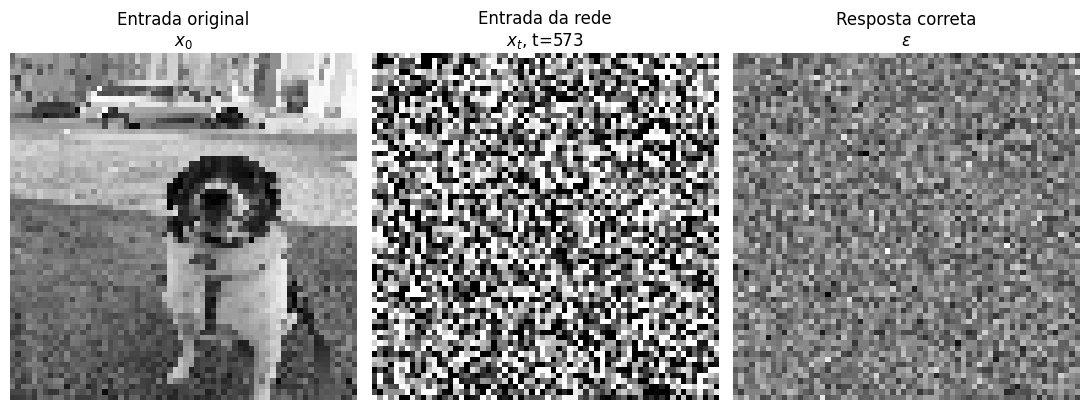

In [53]:
# Sorteia uma etapa aleatória
t = np.random.randint(0, T)

# Sorteia um novo ruído para este exemplo
epsilon_alvo = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x0.shape
).astype(np.float32)

# Calcula diretamente x_t
xt, _, _ = adicionar_ruido_direto(
    x0,
    t,
    epsilon_alvo
)

fig, eixos = plt.subplots(1, 3, figsize=(11, 4))

eixos[0].imshow(x0, cmap="gray", vmin=-1, vmax=1)
eixos[0].set_title("Entrada original\n$x_0$")

eixos[1].imshow(xt, cmap="gray", vmin=-1, vmax=1)
eixos[1].set_title(f"Entrada da rede\n$x_t$, t={t + 1}")

eixos[2].imshow(epsilon_alvo, cmap="gray")
eixos[2].set_title("Resposta correta\n$\\epsilon$")

for eixo in eixos:
    eixo.axis("off")

plt.tight_layout()
plt.show()